# EDA 05 - Phân tích tương quan

Notebook này dùng để chạy lại script phân tích tương quan và xem nhanh các bảng, biểu đồ trọng tâm. Nội dung chính vẫn được sinh tự động ở `EDA/docs/05-correlation/`.

In [1]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd().resolve()
ROOT = cwd.parents[1] if cwd.name == "notebooks" else cwd
SCRIPT = ROOT / "EDA" / "src" / "05_analyze_correlations.py"
TABLE_DIR = ROOT / "EDA" / "outputs" / "tables" / "05_correlation"
FIGURE_DIR = ROOT / "EDA" / "outputs" / "figures" / "05_correlation"

## Chạy lại phân tích

In [2]:
subprocess.run([sys.executable, str(SCRIPT)], check=True)

CompletedProcess(args=['d:\\Tài liệu Bách khoa\\DataWarehouse\\BTN\\.venv\\Scripts\\python.exe', 'D:\\Tài liệu Bách khoa\\DataWarehouse\\BTN\\EDA\\src\\05_analyze_correlations.py'], returncode=0)

## Bảng tương quan trọng tâm

In [3]:
key_correlations = pd.read_csv(TABLE_DIR / "key_correlations.csv")
key_correlations

,segment,x_metric,x_label,y_metric,y_label,n,pearson_corr,spearman_corr,relationship
0,overall,total_click,Total click,avg_score,Average score,25820,0.290345,0.347396,total click vs average score
1,overall,log_total_click,Log1p total click,avg_score,Average score,25820,0.354350,0.347396,log total click vs average score
2,overall,total_click,Total click,weighted_score,Weighted score,23506,0.317709,0.388211,total click vs weighted score
3,overall,log_total_click,Log1p total click,weighted_score,Weighted score,23506,0.364452,0.388211,log total click vs weighted score
4,overall,active_days,Active days,weighted_score,Weighted score,23506,0.359643,0.377834,active days vs weighted score
5,overall,active_weeks,Active weeks,weighted_score,Weighted score,23506,0.361364,0.360973,active weeks vs weighted score
6,overall,interacted_sites,Interacted sites,weighted_score,Weighted score,23506,0.270365,0.272827,interacted sites vs weighted score
7,overall,resource_types_used,Resource types,weighted_score,Weighted score,23506,0.267824,0.259449,resource types vs weighted score
8,overall,submitted_assessments,Submitted assessments,weighted_score,Weighted score,23506,0.228960,0.199474,submitted assessments vs weighted score
9,overall,submitted_weight_sum,Submitted weight,weighted_score,Weighted score,23506,0.166133,0.191069,submitted weight vs weighted score


In [4]:
metrics_by_result = pd.read_csv(TABLE_DIR / "metrics_by_final_result.csv")
metrics_by_result.query("metric in ['total_click', 'active_days', 'weighted_score', 'late_submission_rate']")

,final_result,metric,metric_label,row_count,non_missing_count,mean,p25,median,p75,p90,max
0,Distinction,total_click,Total click,3024,3024,2574.425926,905.750000,1819.000000,3634.500000,5567.700000,17514.00
2,Distinction,active_days,Active days,3024,3024,110.042659,63.000000,103.000000,148.000000,191.000000,286.00
9,Distinction,late_submission_rate,Late submission rate,3024,3024,0.218857,0.000000,0.083333,0.454545,0.555556,1.00
11,Distinction,weighted_score,Weighted score,3024,2628,88.951161,85.500000,89.250000,93.042500,96.171800,100.00
12,Pass,total_click,Total click,12361,12361,1861.999919,655.000000,1294.000000,2488.000000,4075.000000,23513.00
14,Pass,active_days,Active days,12361,12361,87.044495,47.000000,78.000000,117.000000,159.000000,285.00
21,Pass,late_submission_rate,Late submission rate,12361,12358,0.247114,0.000000,0.142857,0.454545,0.636364,1.00
23,Pass,weighted_score,Weighted score,12361,11240,72.478153,65.000000,73.707317,81.000000,86.240000,98.68
24,Fail,total_click,Total click,7052,7052,631.784175,93.000000,305.500000,766.000000,1604.800000,11143.00
26,Fail,active_days,Active days,7052,7052,33.177113,8.000000,22.000000,47.000000,81.000000,230.00


## Biểu đồ trọng tâm

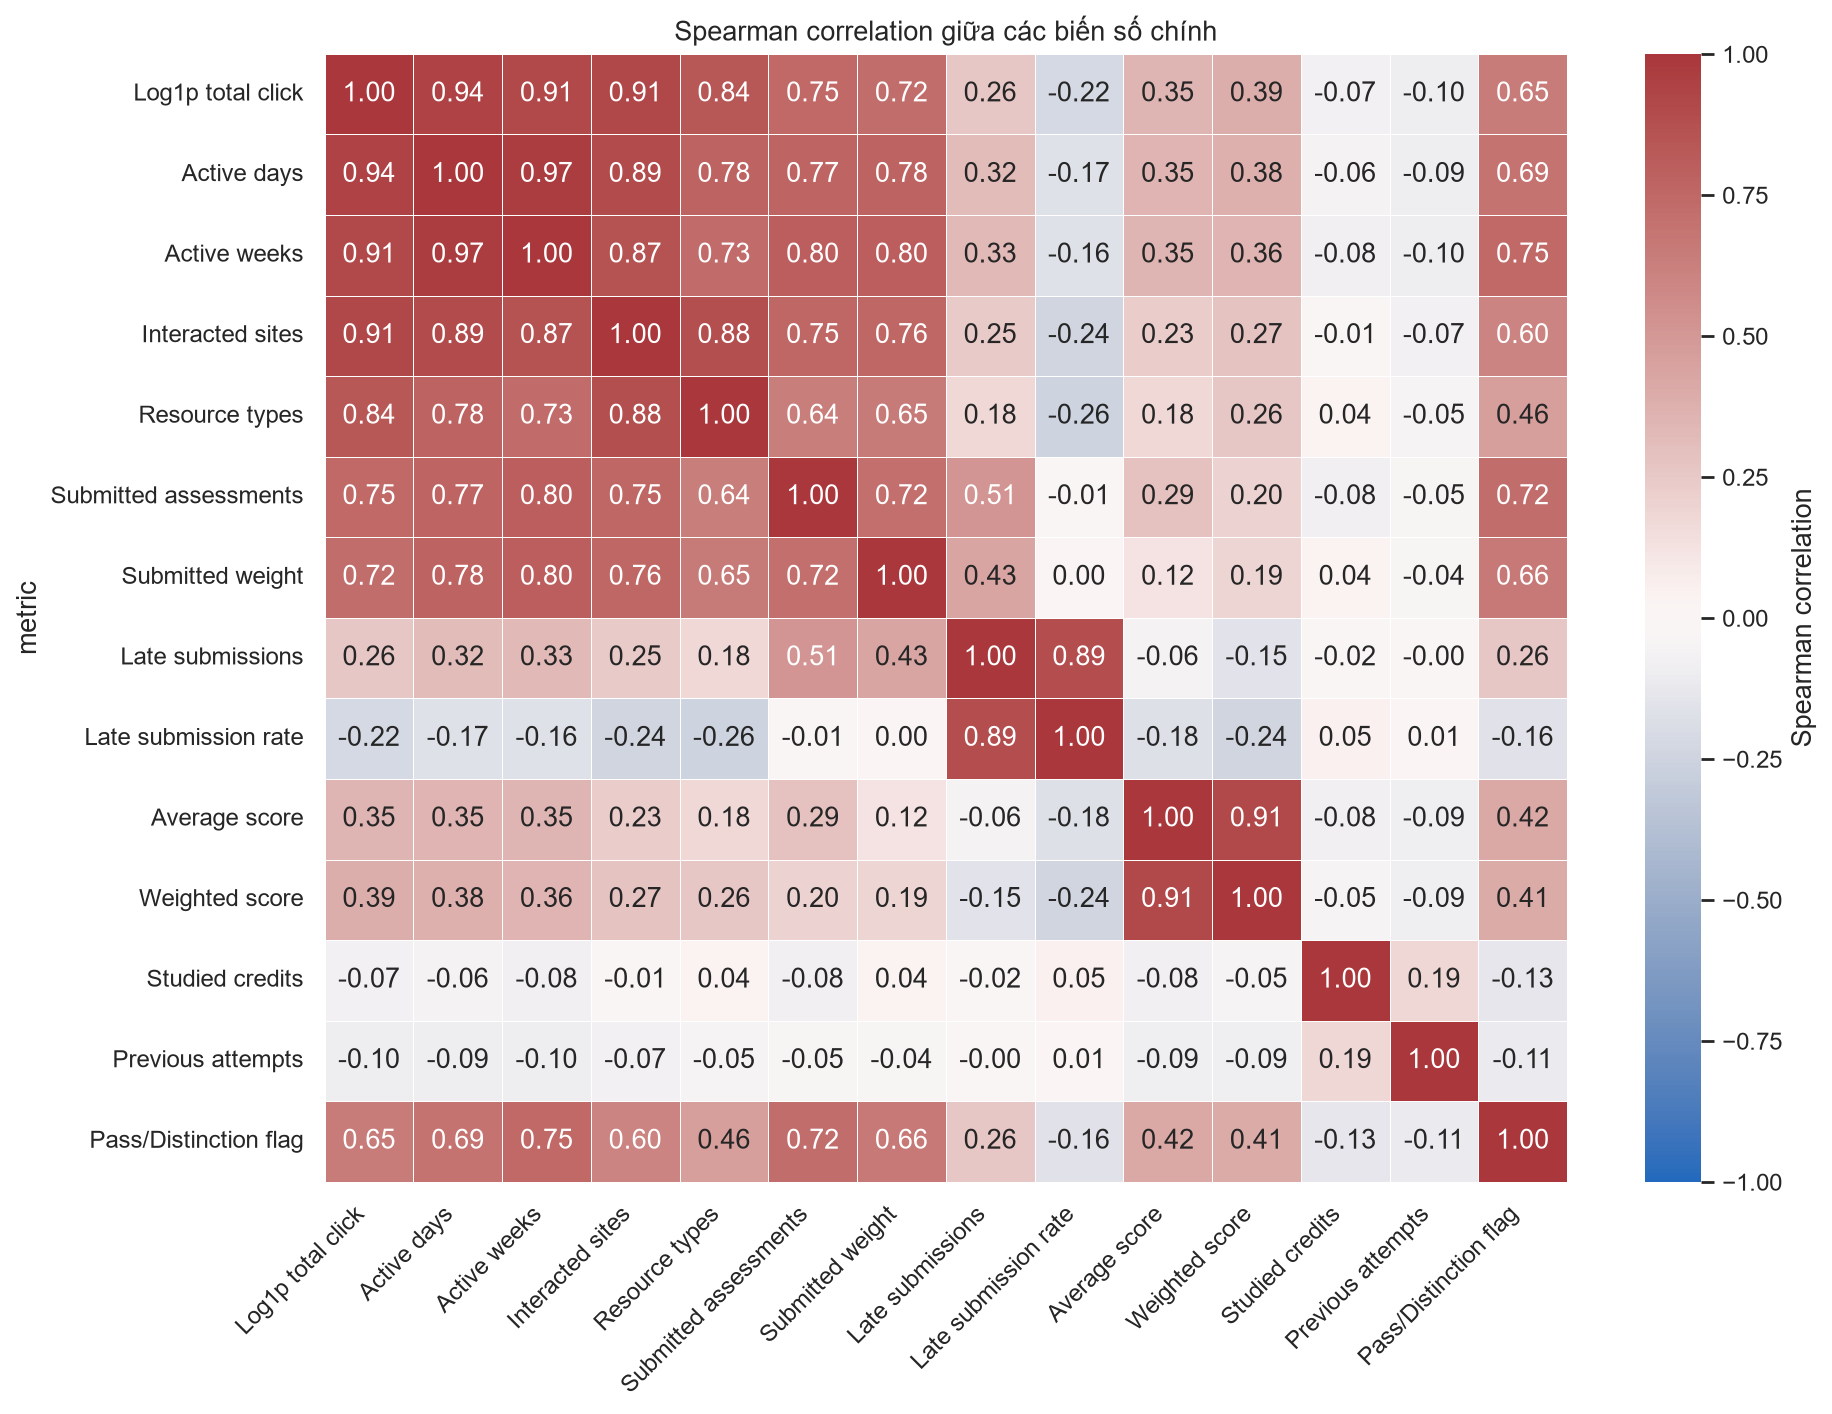

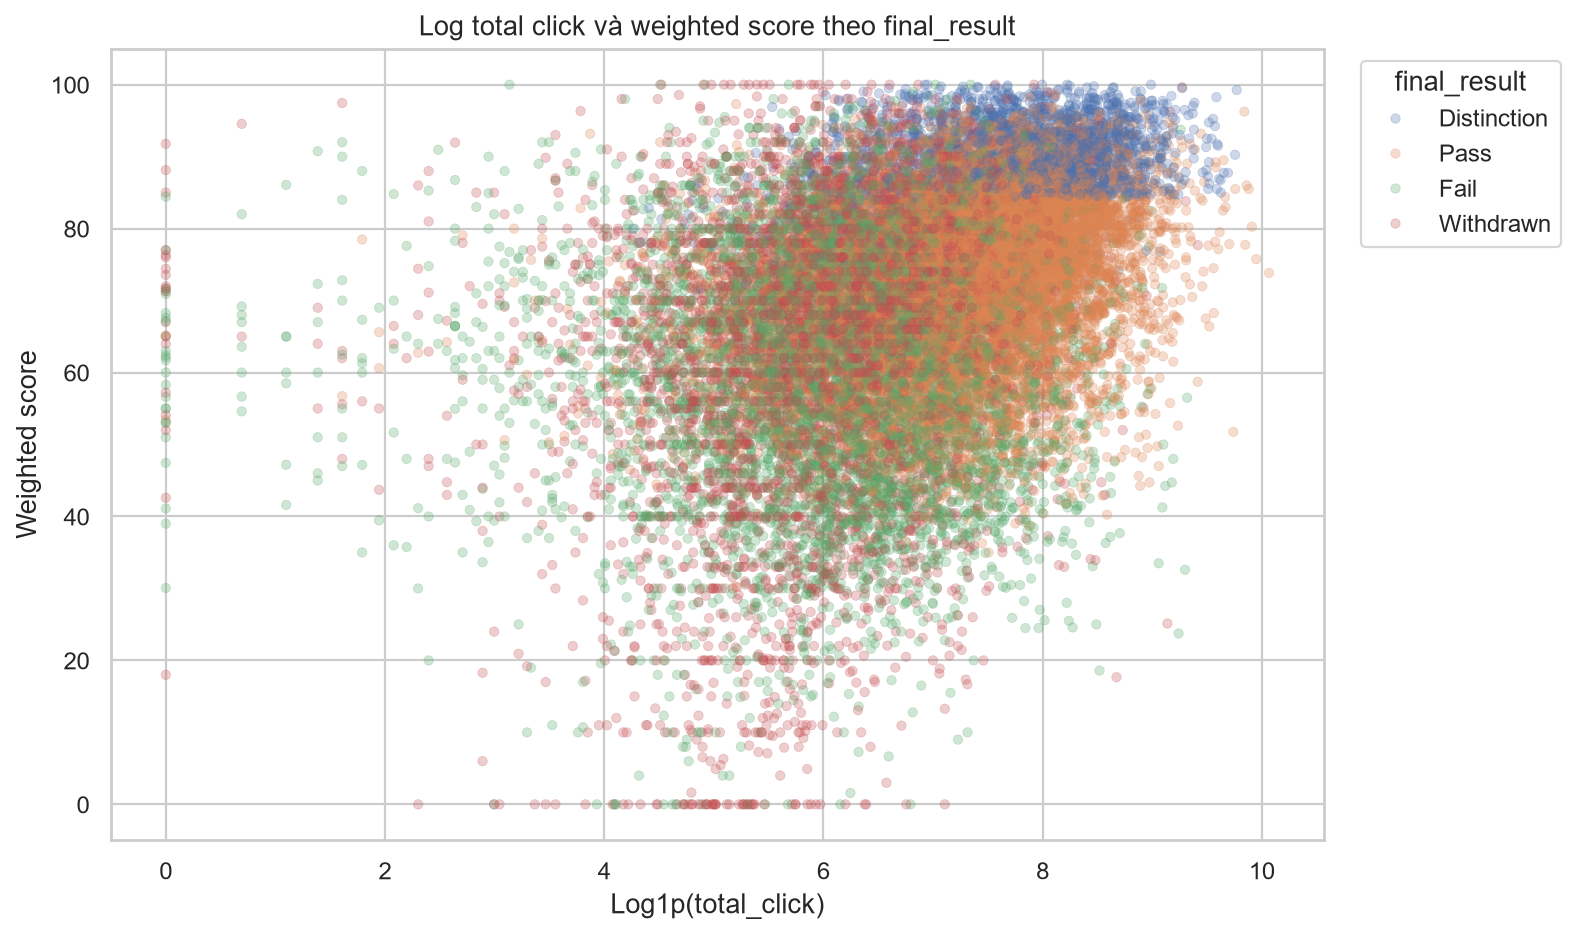

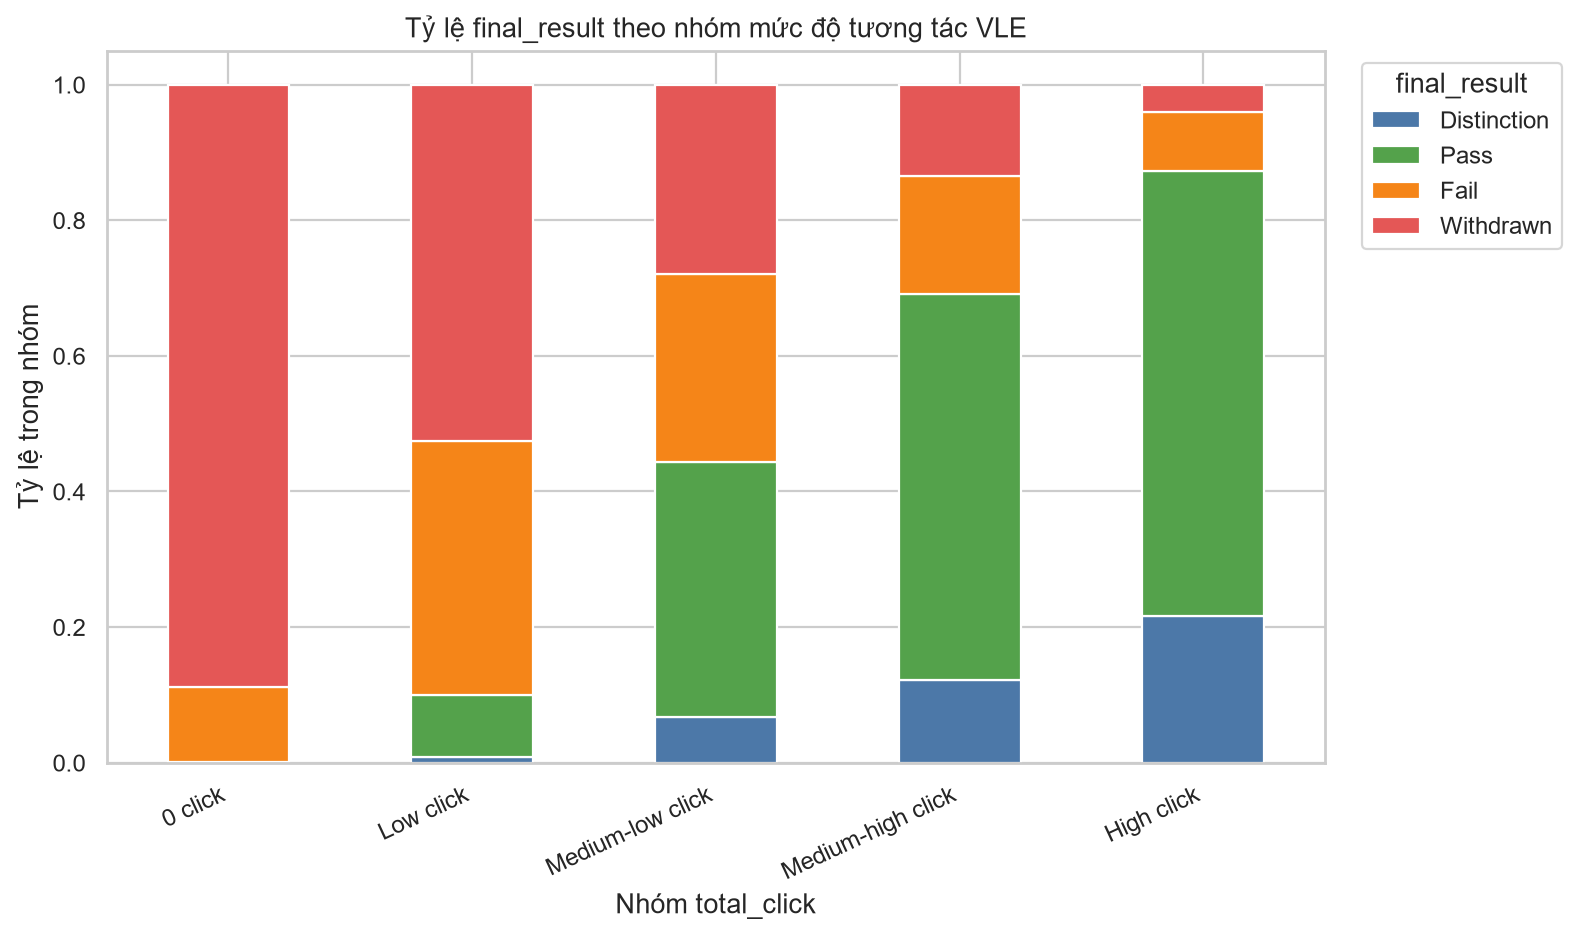

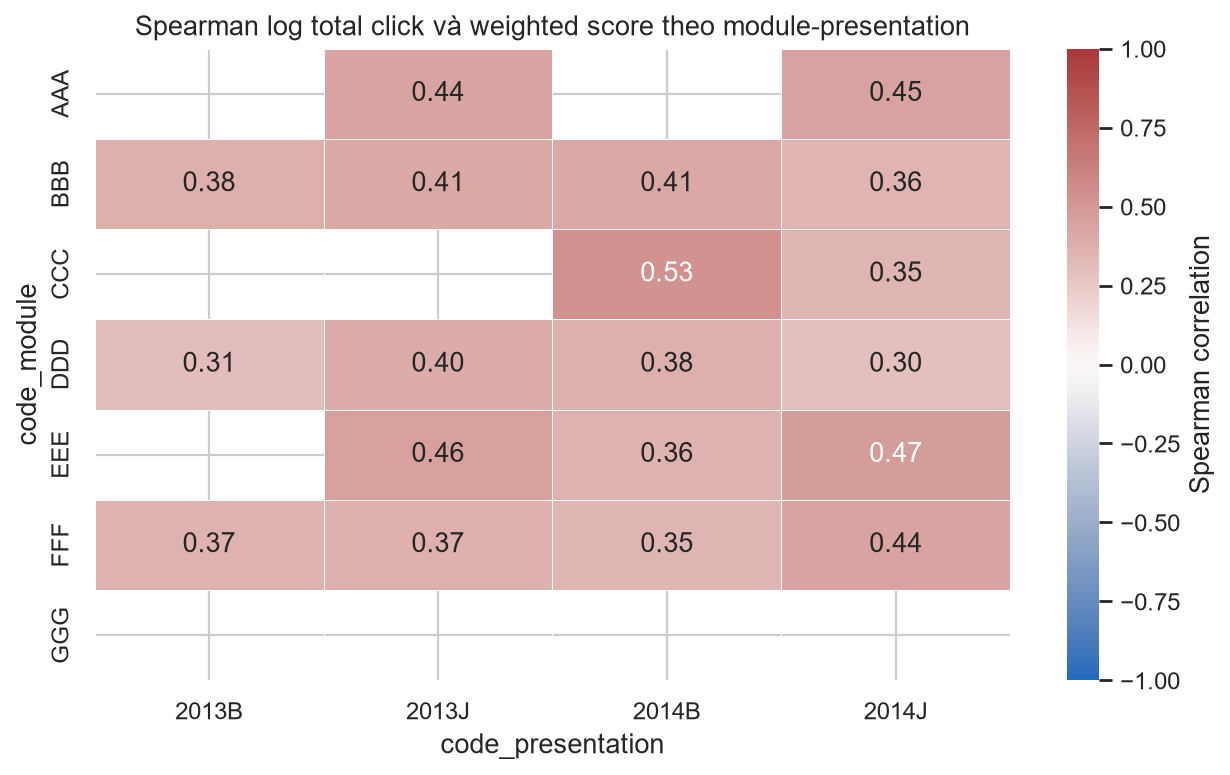

In [5]:
for name in [
    "numeric_spearman_correlation_heatmap.png",
    "log_total_click_vs_weighted_score_scatter.png",
    "final_result_by_engagement_band_stacked.png",
    "module_presentation_click_score_spearman_heatmap.png",
]:
    display(Image(filename=str(FIGURE_DIR / name)))